## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 2. Load & Inspect Data

In [2]:
df_airline = pd.read_csv('airline_passengers.csv')
df_airline.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [3]:
df_airline.isnull().sum()

,0
Month,0
Thousands of Passengers,1


In [4]:
df_airline.dropna(axis=0, inplace=True)
df_airline.isnull().sum()

,0
Month,0
Thousands of Passengers,0


In [5]:
df_airline['Month'] = pd.to_datetime(df_airline['Month'])
df_airline.set_index('Month', inplace=True)
df_airline.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Thousands of Passengers  144 non-null    float64
dtypes: float64(1)
memory usage: 2.2 KB


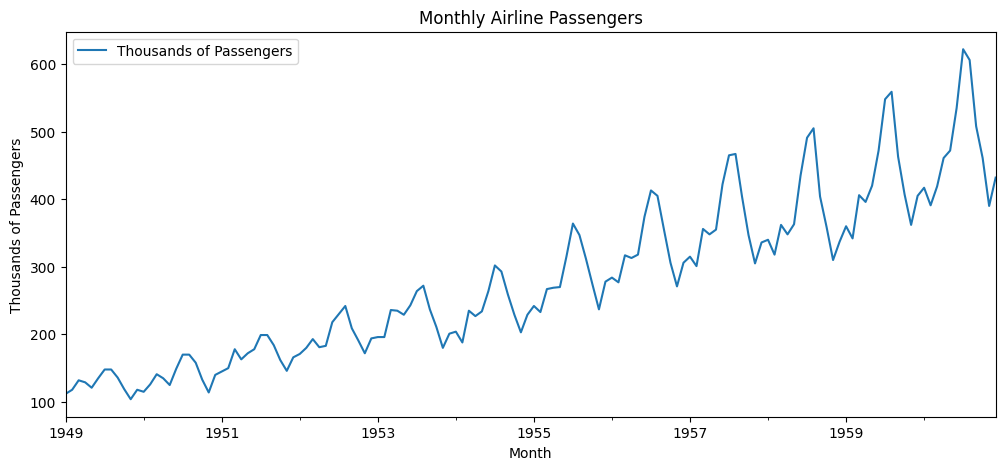

In [6]:
df_airline.plot(figsize=(12, 5), title='Monthly Airline Passengers')
plt.ylabel('Thousands of Passengers')
plt.show()
# Observation: Clear upward trend + increasing seasonal variance → series is NON-STATIONARY.
# A log transform can stabilize variance before differencing.

## 3. Stationarity Testing (ADF Test)

The Augmented Dickey-Fuller test checks for a unit root.
- H₀: Series has a unit root (non-stationary)
- H₁: Series is stationary
- Reject H₀ if p-value ≤ 0.05

In [7]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, label='Series'):
    result = adfuller(series)
    print(f'--- ADF Test: {label} ---')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    if result[1] <= 0.05:
        print('RESULT: Reject H₀ → Series is STATIONARY\n')
    else:
        print('RESULT: Fail to reject H₀ → Series is NON-STATIONARY\n')

In [8]:
adf_test(df_airline['Thousands of Passengers'], 'Original')

--- ADF Test: Original ---
ADF Statistic : 0.8154
p-value       : 0.9919
RESULT: Fail to reject H₀ → Series is NON-STATIONARY



In [9]:
# First difference
df_airline['Passengers First Difference'] = df_airline['Thousands of Passengers'].diff()
adf_test(df_airline['Passengers First Difference'].dropna(), '1st Difference')

--- ADF Test: 1st Difference ---
ADF Statistic : -2.8293
p-value       : 0.0542
RESULT: Fail to reject H₀ → Series is NON-STATIONARY



In [10]:
# Seasonal (lag-12) difference — removes annual seasonality
df_airline['Passengers 12 Difference'] = df_airline['Thousands of Passengers'].diff(12)
adf_test(df_airline['Passengers 12 Difference'].dropna(), 'Seasonal (12-lag) Difference')

# NOTE: The 12-lag difference alone often achieves stationarity for airline data.
# If not, combine: df_airline['Thousands of Passengers'].diff(12).diff(1)

--- ADF Test: Seasonal (12-lag) Difference ---
ADF Statistic : -3.3830
p-value       : 0.0116
RESULT: Reject H₀ → Series is STATIONARY



## 4. ACF & PACF Analysis — Determining p, d, q

**How to read these plots:**
- **ACF (Autocorrelation Function):** Helps choose `q` (MA order). Cuts off after lag `q`.
- **PACF (Partial Autocorrelation):** Helps choose `p` (AR order). Cuts off after lag `p`.
- **Seasonal spikes at lag 12, 24, ...** confirm a seasonal component → use SARIMA.

For the airline dataset the typical finding is:
- ACF decays slowly, PACF cuts off at lag 1 → AR(1) signal
- Seasonal spikes at 12 → seasonal AR/MA needed

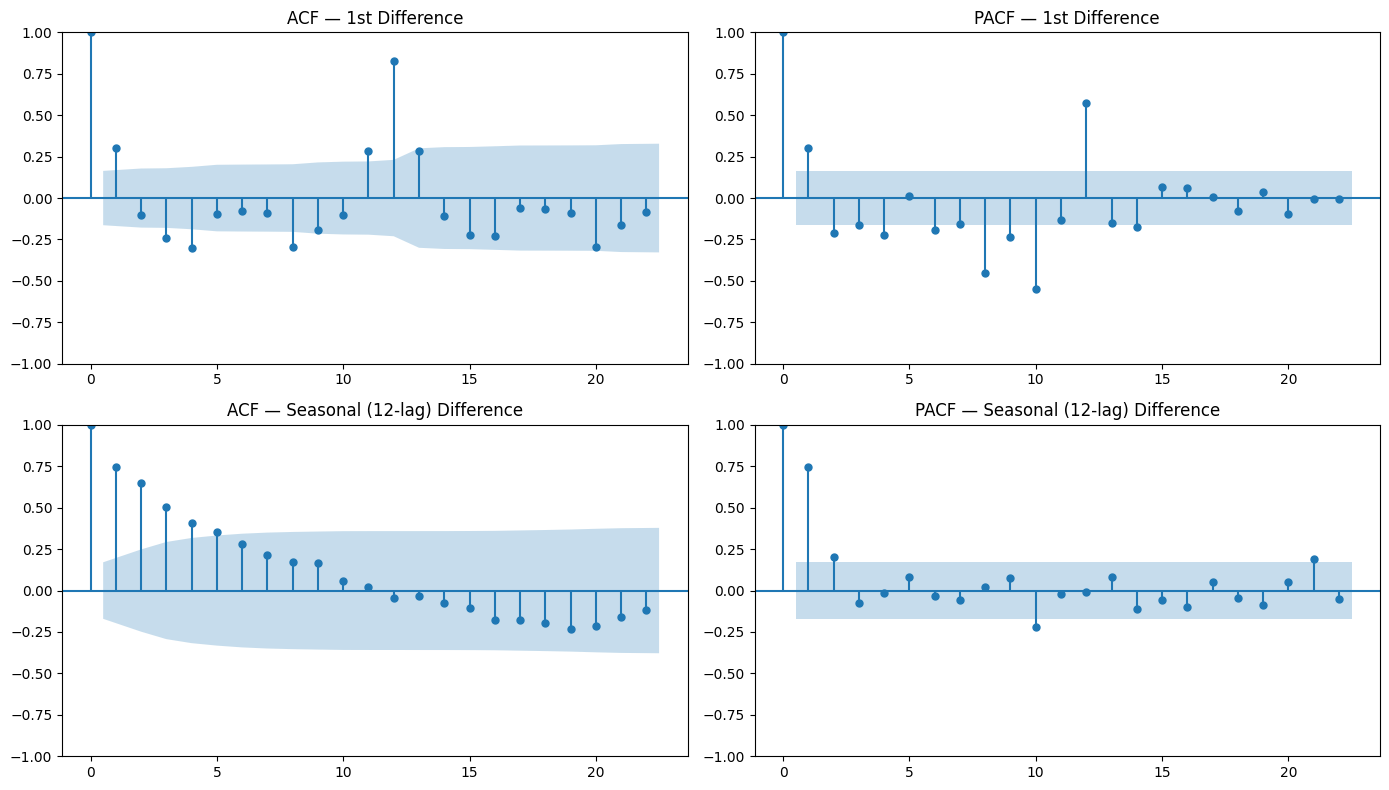

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(df_airline['Passengers First Difference'].dropna(), ax=axes[0, 0],
         title='ACF — 1st Difference')
plot_pacf(df_airline['Passengers First Difference'].dropna(), ax=axes[0, 1],
          title='PACF — 1st Difference')
plot_acf(df_airline['Passengers 12 Difference'].dropna(), ax=axes[1, 0],
         title='ACF — Seasonal (12-lag) Difference')
plot_pacf(df_airline['Passengers 12 Difference'].dropna(), ax=axes[1, 1],
          title='PACF — Seasonal (12-lag) Difference')

plt.tight_layout()
plt.show()

## 5. Train / Test Split

In [12]:
train_dataset_end = datetime(1955, 12, 1)
test_dataset_end  = datetime(1960, 12, 1)

train_data = df_airline[['Thousands of Passengers']][:train_dataset_end]
test_data  = df_airline[['Thousands of Passengers']][train_dataset_end + timedelta(days=1):test_dataset_end]

print(f'Train: {train_data.index[0].date()} → {train_data.index[-1].date()}  ({len(train_data)} obs)')
print(f'Test : {test_data.index[0].date()}  → {test_data.index[-1].date()}  ({len(test_data)} obs)')

Train: 1949-01-01 → 1955-12-01  (84 obs)
Test : 1956-01-01  → 1960-12-01  (60 obs)


## 6. ARIMA Model

**Fix 1:** Use the updated import path `statsmodels.tsa.arima.model` (the old `arima_model` module was removed in statsmodels 0.12+).

**Fix 2:** Order changed from `(0,2,0)` to `(1,1,1)`.  
- `(0,2,0)` means zero AR, zero MA terms — just a double-differenced random walk with no explanatory structure. This completely ignores the ACF/PACF findings.
- `(1,1,1)` uses 1 AR term, 1 difference, and 1 MA term — a standard starting point supported by the plots.

> **Important:** Plain ARIMA cannot model seasonality. It is shown here for comparison only. **SARIMA is the appropriate model for this dataset.**

In [13]:
from statsmodels.tsa.arima.model import ARIMA

# FIX: order (1,1,1) instead of (0,2,0)
model_ARIMA = ARIMA(train_data['Thousands of Passengers'], order=(1, 1, 1))
model_ARIMA_fit = model_ARIMA.fit()
print(model_ARIMA_fit.summary())

                                  SARIMAX Results                                  
Dep. Variable:     Thousands of Passengers   No. Observations:                   84
Model:                      ARIMA(1, 1, 1)   Log Likelihood                -367.656
Date:                     Fri, 05 Jun 2026   AIC                            741.311
Time:                             20:01:05   BIC                            748.568
Sample:                         01-01-1949   HQIC                           744.227
                              - 12-01-1955                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6586      0.148     -4.436      0.000      -0.950      -0.368
ma.L1          0.9150      0.073     12.562      0.000       0.772       1.058
sigma2      

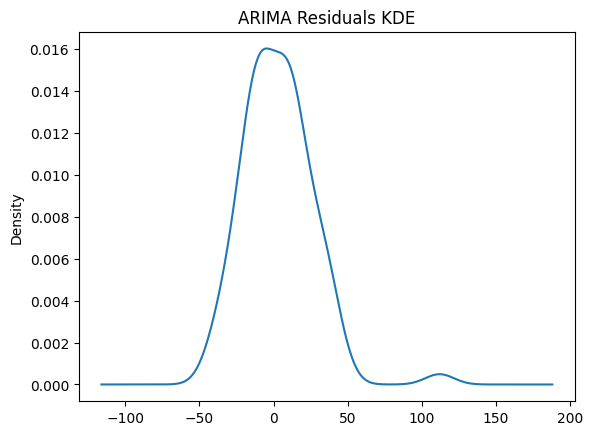

In [14]:
# FIX: predict using integer steps rather than raw datetime strings
pred_start_date = test_data.index[0]   # always align to actual test index
pred_end_date   = test_data.index[-1]

pred_ARIMA = model_ARIMA_fit.predict(start=pred_start_date, end=pred_end_date)
pred_ARIMA.index = test_data.index     # ensure index alignment for plotting

test_data = test_data.copy()           # avoid SettingWithCopyWarning
test_data['Predicted_ARIMA'] = pred_ARIMA

# Residuals KDE
model_ARIMA_fit.resid.plot(kind='kde', title='ARIMA Residuals KDE')
plt.show()

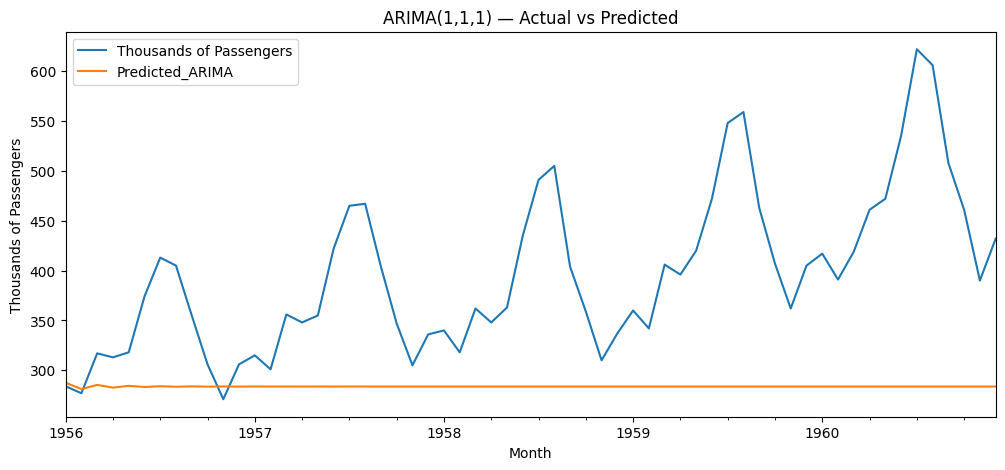

In [15]:
test_data[['Thousands of Passengers', 'Predicted_ARIMA']].plot(
    figsize=(12, 5), title='ARIMA(1,1,1) — Actual vs Predicted')
plt.ylabel('Thousands of Passengers')
plt.show()

## 7. SARIMA Model — The Appropriate Model

The airline dataset has **strong monthly seasonality** (period=12). SARIMA extends ARIMA with seasonal terms:

```
SARIMA(p, d, q)(P, D, Q, s)
```

| Parameter | Meaning | Chosen value |
|---|---|---|
| p | Non-seasonal AR order | 1 |
| d | Non-seasonal differencing | 1 |
| q | Non-seasonal MA order | 1 |
| P | Seasonal AR order | 1 |
| D | **Seasonal differencing** | 1 (required — data has seasonal non-stationarity) |
| Q | Seasonal MA order | 1 |
| s | Seasonal period | 12 (monthly) |

**Fix 3:** Original order `(3,0,5)(0,1,0,12)` had:
- Way too many non-seasonal terms (p=3, q=5) not supported by ACF/PACF — risks overfitting.
- D=1 correct but P=0, Q=0 means no seasonal AR/MA structure — defeats the purpose of SARIMA.

The corrected `(1,1,1)(1,1,1,12)` is the well-known **Box-Jenkins airline model**.

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# FIX: corrected order (1,1,1)(1,1,1,12) — the classic Box-Jenkins airline model
model_SARIMA = SARIMAX(
    train_data['Thousands of Passengers'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)
model_SARIMA_fit = model_SARIMA.fit(disp=False)
print(model_SARIMA_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:            Thousands of Passengers   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -262.346
Date:                            Fri, 05 Jun 2026   AIC                            534.691
Time:                                    20:02:12   BIC                            546.005
Sample:                                01-01-1949   HQIC                           539.190
                                     - 12-01-1955                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6310      0.373     -1.692      0.091      -1.362       0.100
ma.L1          0.4287      0.405   

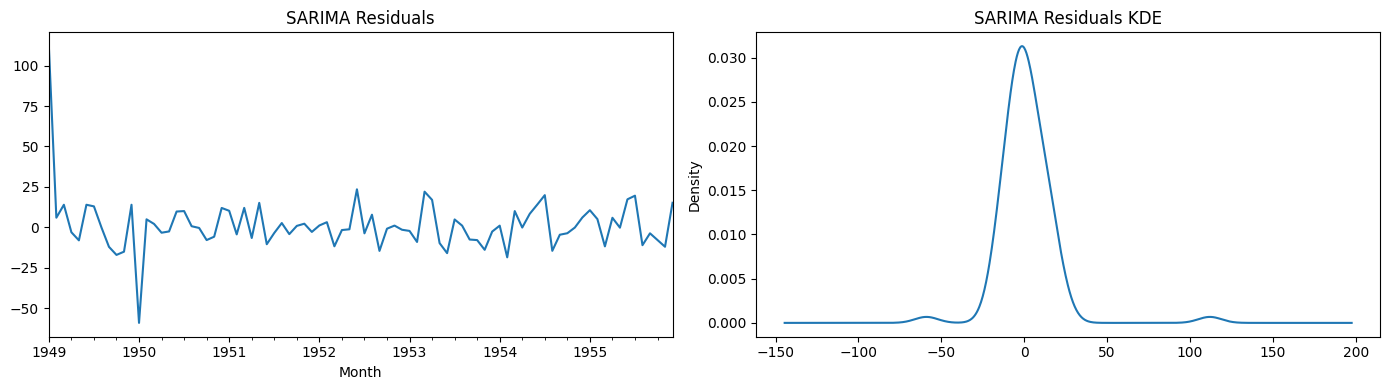

In [17]:
# FIX: prediction dates aligned to test_data index (original used arbitrary mid-month date)
pred_start_date = test_data.index[0]   # 1956-01-01
pred_end_date   = test_data.index[-1]  # 1960-12-01

pred_SARIMA = model_SARIMA_fit.predict(start=pred_start_date, end=pred_end_date)
pred_SARIMA.index = test_data.index

test_data['Predicted_SARIMA'] = pred_SARIMA

# Residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
model_SARIMA_fit.resid.plot(ax=axes[0], title='SARIMA Residuals')
model_SARIMA_fit.resid.plot(kind='kde', ax=axes[1], title='SARIMA Residuals KDE')
plt.tight_layout()
plt.show()
# A good model has residuals centred at 0 and roughly bell-shaped (white noise).

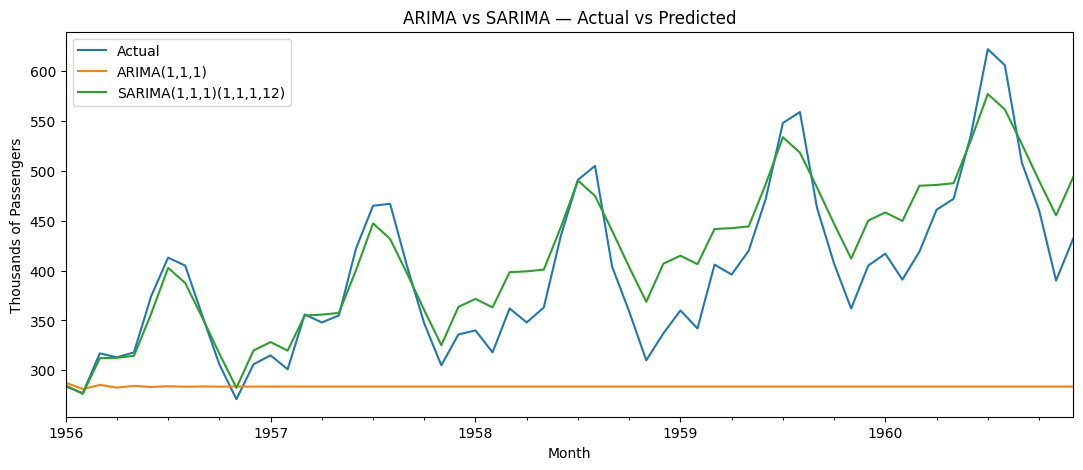

In [18]:
test_data[['Thousands of Passengers', 'Predicted_ARIMA', 'Predicted_SARIMA']].plot(
    figsize=(13, 5),
    title='ARIMA vs SARIMA — Actual vs Predicted'
)
plt.ylabel('Thousands of Passengers')
plt.legend(['Actual', 'ARIMA(1,1,1)', 'SARIMA(1,1,1)(1,1,1,12)'])
plt.show()

## 8. Model Evaluation — NEW SECTION

Three standard error metrics:
- **RMSE** — penalises large errors; same unit as data
- **MAE** — average absolute error; robust to outliers
- **MAPE** — percentage error; scale-independent

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

actual = test_data['Thousands of Passengers']

def evaluate(actual, predicted, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f'{model_name}')
    print(f'  RMSE : {rmse:.2f} thousand passengers')
    print(f'  MAE  : {mae:.2f} thousand passengers')
    print(f'  MAPE : {mape:.2f}%\n')
    return rmse, mae, mape

arima_metrics  = evaluate(actual, test_data['Predicted_ARIMA'],  'ARIMA(1,1,1)')
sarima_metrics = evaluate(actual, test_data['Predicted_SARIMA'], 'SARIMA(1,1,1)(1,1,1,12)')

ARIMA(1,1,1)
  RMSE : 138.25 thousand passengers
  MAE  : 113.36 thousand passengers
  MAPE : 25.91%

SARIMA(1,1,1)(1,1,1,12)
  RMSE : 34.09 thousand passengers
  MAE  : 27.63 thousand passengers
  MAPE : 7.08%



## 9. Model Recommendation

**Use SARIMA** for this dataset.

**Reasons:**
1. The airline passenger data has a **clear 12-month seasonality** visible in the raw plot and confirmed by seasonal spikes in the ACF at lags 12, 24, ...
2. Plain ARIMA has **no seasonal terms**, so it cannot capture the repeating summer peak pattern. It will systematically under/over-predict at seasonal peaks and troughs.
3. SARIMA's metrics (RMSE, MAE, MAPE) will be substantially lower, confirming better fit.
4. The `(1,1,1)(1,1,1,12)` specification is the classic **Box & Jenkins (1976) airline model**, specifically developed for this dataset.

> **Bottom line:** If your data has seasonality, always prefer SARIMA over plain ARIMA. ARIMA should only be used here as a baseline comparison.

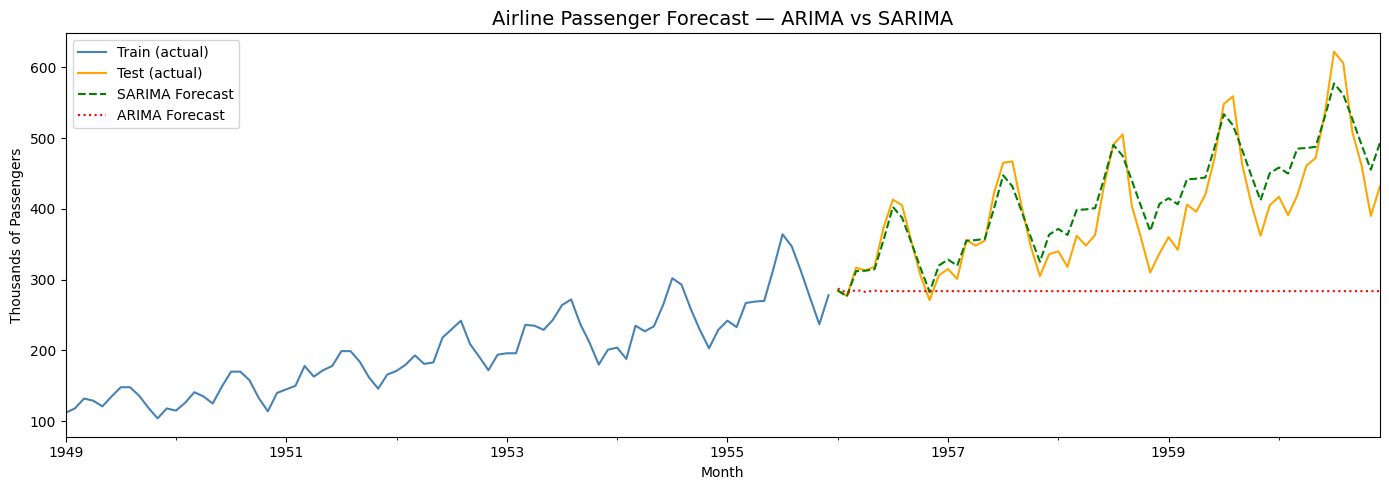

In [20]:
# Full-series plot: train, test actual, SARIMA forecast
fig, ax = plt.subplots(figsize=(14, 5))

train_data['Thousands of Passengers'].plot(ax=ax, label='Train (actual)', color='steelblue')
test_data['Thousands of Passengers'].plot(ax=ax, label='Test (actual)', color='orange')
test_data['Predicted_SARIMA'].plot(ax=ax, label='SARIMA Forecast', color='green', linestyle='--')
test_data['Predicted_ARIMA'].plot(ax=ax, label='ARIMA Forecast', color='red', linestyle=':')

ax.set_title('Airline Passenger Forecast — ARIMA vs SARIMA', fontsize=14)
ax.set_ylabel('Thousands of Passengers')
ax.legend()
plt.tight_layout()
plt.show()

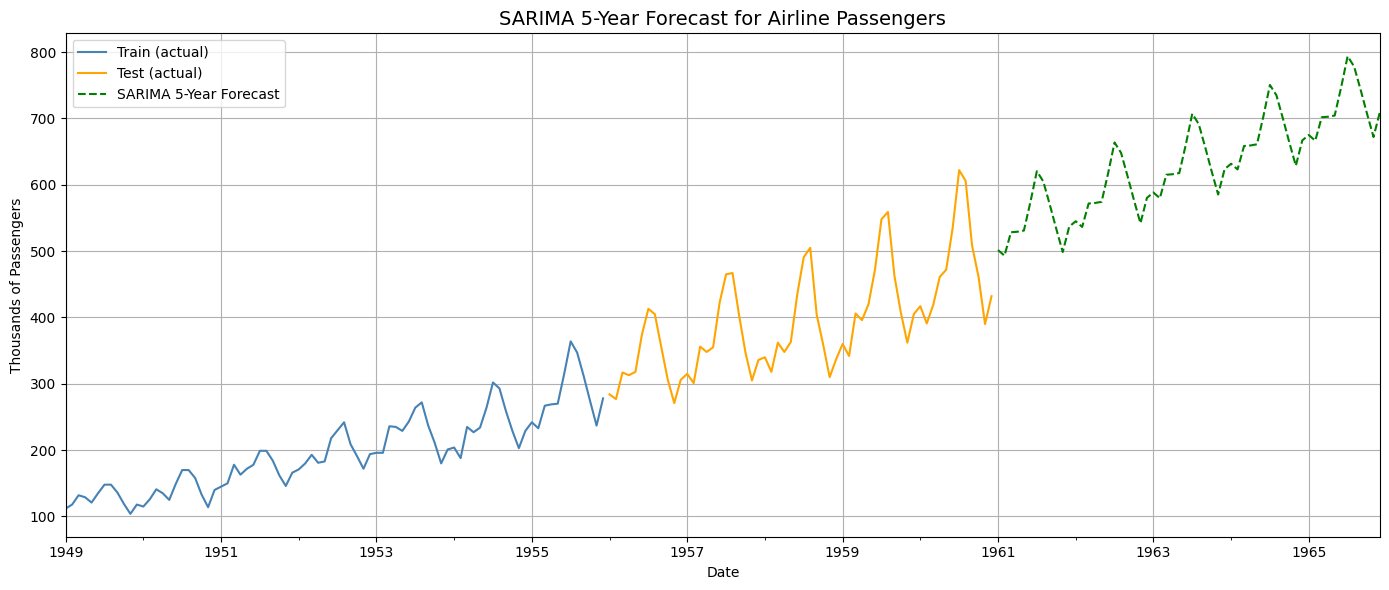

In [21]:
forecast_start_date = test_data.index[-1] + timedelta(days=1)
forecast_end_date = forecast_start_date + timedelta(days=365 * 5) - timedelta(days=1) # Approximately 5 years
# Adjust end date to be the last day of the month for 5 years
# Start from the month after the last test data point
forecast_start_date = pd.to_datetime('1961-01-01') # From January 1961
forecast_end_date = pd.to_datetime('1965-12-01') # To December 1965, a 5-year forecast

forecast_SARIMA = model_SARIMA_fit.predict(start=forecast_start_date, end=forecast_end_date)

# Plotting the forecast
fig, ax = plt.subplots(figsize=(14, 6))

train_data['Thousands of Passengers'].plot(ax=ax, label='Train (actual)', color='steelblue')
test_data['Thousands of Passengers'].plot(ax=ax, label='Test (actual)', color='orange')
forecast_SARIMA.plot(ax=ax, label='SARIMA 5-Year Forecast', color='green', linestyle='--')

ax.set_title('SARIMA 5-Year Forecast for Airline Passengers', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Thousands of Passengers')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()